In [21]:
from typing_extensions import TypedDict, NotRequired
from pathlib import Path

from langgraph.graph import StateGraph, START, END

from spm_agent.mcp.scifireaders_service import SciFiReadersService
import json

from IPython.display import Image, display
from PIL import Image as PILImage
import numpy as np
import os

In [18]:
#states

class ChannelStats(TypedDict):
    min: float
    max: float
    mean: float
    std: float
    p01: float
    p99: float

class Channel(TypedDict):
    title: str
    units: str
    data_type: str
    shape: list
    preview_path: str
    stats: ChannelStats

class ImageAnalysisState(TypedDict):
    #input
    file_path: str

    file_channels: NotRequired[dict[str, Channel]]
    pass

In [19]:
# auxilary functions
def get_channel_stats(array) -> dict:
    """
    Get basic image stats
    """
    return {
        "min": float(np.nanmin(array)),
        "max": float(np.nanmax(array)),
        "mean": float(np.nanmean(array)),
        "std": float(np.nanstd(array)),
        "p01": float(np.nanpercentile(array, 1)),
        "p99": float(np.nanpercentile(array, 99)),
    }

def save_preview(channel) -> dict:
    """
    Save a PNG preview to the cache for later vision-model review.
    """
    from spm_agent.config import CASHE_DIR
    CASHE_DIR.mkdir(parents=True, exist_ok=True)
    
    title = channel['title']
    im_path = os.path.join(CASHE_DIR, f'{title}.png')

    data = np.array(channel['data'])
    norm_data = (data - data.min())/np.ptp(data)
    image = PILImage.fromarray((norm_data * 255).astype(np.uint8))

    try:
        image.save(im_path, format="PNG")

        return {
            "ok": True,
            "path": str(im_path),
            "error": None,
        }
    
    except Exception as exc:
        return {
            "ok": False,
            "path": str(im_path),
            "error": str(exc),
        }


In [ ]:
#nodes
async def readfile_node(state: ImageAnalysisState) -> ImageAnalysisState:
    """
    Read an SPM file and prepare channel metadata, stats, and preview paths.
    """
    
    file_path = state["file_path"]
    
    channels = {}
    ch_keys = ['title', 'units', 'data_type', 'shape']

    #read channel
    service = SciFiReadersService()

    payload = await service.read_file(
        file_path,
    )

    payload_dict = json.loads(payload.content[0].text)

    #create dict
    for k in payload_dict['datasets']:
        channels[k] = {kk: payload_dict['datasets'][k][kk] for kk in ch_keys} 
        channels[k]['stats'] = get_channel_stats(payload_dict['datasets'][k]['data'])
        preview = save_preview(payload_dict['datasets'][k])

        if preview['ok']:
            channels[k]['preview_path'] = preview['path']
        else:
            print(preview['error'])

    return {
        'file_channels': channels
    }

In [22]:
builder = StateGraph(ImageAnalysisState, input_schema=ImageAnalysisState, output_schema=ImageAnalysisState)

builder.add_node('readfile_node', readfile_node)

builder.add_edge(START, 'readfile_node')
builder.add_edge('readfile_node', END)

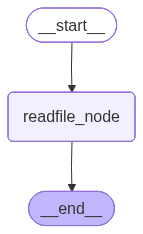

In [23]:
im_graph = builder.compile()
display(Image(im_graph.get_graph().draw_mermaid_png()))

In [28]:
result = await im_graph.ainvoke({'file_path': '/Users/borisslautin/Downloads/PLZT_0001.ibw'})

In [30]:
result

{'file_path': '/Users/borisslautin/Downloads/PLZT_0001.ibw',
 'file_channels': {'Channel_000': {'title': 'HeightRetrace',
   'units': 'm',
   'data_type': 'IMAGE',
   'shape': [128, 128],
   'stats': {'min': -3.603290110731905e-09,
    'max': 9.25687970720901e-09,
    'mean': 3.8163916471489756e-17,
    'std': 1.101515902176863e-09,
    'p01': -2.201375366439606e-09,
    'p99': 3.989770647194746e-09},
   'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.png'},
  'Channel_001': {'title': 'Amplitude1Retrace',
   'units': 'm',
   'data_type': 'IMAGE',
   'shape': [128, 128],
   'stats': {'min': 1.5509754938691778e-11,
    'max': 1.8763145204214737e-10,
    'mean': 7.699618017554798e-11,
    'std': 2.6974230031321476e-11,
    'p01': 2.5241057837604996e-11,
    'p99': 1.4132463241334215e-10},
   'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/Amplitude1Retrace.png'},
  'Channe

In [9]:
payload_dict = json.loads(payload.content[0].text)
payload_dict.keys()

dict_keys(['file_path', 'return_mode', 'available_readers', 'matched_readers', 'selected_reader', 'dataset_count', 'datasets'])

In [70]:
channels

{'Channel_000': {'title': 'HeightRetrace',
  'units': 'm',
  'data_type': 'IMAGE',
  'shape': [128, 128],
  'stats': {'min': -3.603290110731905e-09,
   'max': 9.25687970720901e-09,
   'mean': 3.8163916471489756e-17,
   'std': 1.101515902176863e-09,
   'p01': -2.201375366439606e-09,
   'p99': 3.989770647194746e-09}},
 'Channel_001': {'title': 'Amplitude1Retrace',
  'units': 'm',
  'data_type': 'IMAGE',
  'shape': [128, 128],
  'stats': {'min': 1.5509754938691778e-11,
   'max': 1.8763145204214737e-10,
   'mean': 7.699618017554798e-11,
   'std': 2.6974230031321476e-11,
   'p01': 2.5241057837604996e-11,
   'p99': 1.4132463241334215e-10}},
 'Channel_002': {'title': 'Amplitude2Retrace',
  'units': 'm',
  'data_type': 'IMAGE',
  'shape': [128, 128],
  'stats': {'min': 1.3011540629659368e-11,
   'max': 2.719347802493388e-10,
   'mean': 7.744286381841048e-11,
   'std': 3.038732911086011e-11,
   'p01': 2.269102463217654e-11,
   'p99': 1.5468922781591843e-10}},
 'Channel_003': {'title': 'Phase1Re

In [57]:
dat = payload_dict['datasets']['Channel_003']['data']

In [58]:
dat_ar = np.array(dat)

In [59]:
norm_dat_ar = (dat_ar - dat_ar.min())/np.ptp(dat_ar)

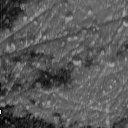

In [60]:
PILImage.fromarray((norm_dat_ar * 255).astype(np.uint8))

In [73]:
cache_dir = Path(".cache/current")
cache_dir

PosixPath('.cache/current')

In [74]:
cache_dir.mkdir(parents=True, exist_ok=True)